**Transient & MCMC II: nested sempling**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import dynesty

In [4]:
data = np.load("../Solutions/transient.npy")
time, flux, error = data.T

In [8]:
# Define the model
def Model(t, b, A, alpha, t0):
    return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))

# Define the log-likelihood
def logLikelihood(theta, t, flux, error):
    b, A, alpha, t0 = theta
    model = Model(t, b, A, alpha, t0)
    logL = -0.5 * np.sum(((flux - model) / error) ** 2)
    return logL

# Define the prior transformation
def priorTransform(u):
    b = 50 * u[0]  # Map u[0] from [0, 1] to [0, 50]
    A = 50 * u[1]  # Map u[1] from [0, 1] to [0, 50]
    logalpha = -5 + 10 * u[2]  # Map u[2] from [0, 1] to [-5, 5]
    t0 = 100 * u[3]  # Map u[3] from [0, 1] to [0, 100]

    alpha = np.exp(logalpha)  # Convert logalpha to alpha

    return b, A, alpha, t0

In [12]:
ndim = 4
sampler = dynesty.NestedSampler(logLikelihood, priorTransform, ndim, nlive = 500, logl_args=(time, flux, error))
sampler.run_nested()
samples = sampler.results['samples']

/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_92384/269179680.py:3: RuntimeWarning: overflow encountered in exp
  return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))
/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_92384/269179680.py:3: RuntimeWarning: overflow encountered in multiply
  return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))
1568it [00:00, 2456.24it/s, bound: 0 | nc: 21 | ncall: 11370 | eff(%): 13.791 | loglstar:   -inf < -274.986 <    inf | logz: -284.171 +/-  0.124 | dlogz: 209.707 >  0.509]  /var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_92384/269179680.py:3: RuntimeWarning: overflow encountered in exp
  return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))
/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_92384/269179680.py:3: RuntimeWarning: overflow encountered in multiply
  return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))
1826it [00:00, 1450.03it/s, bound: 1 | nc: 9 | ncall: 18141 |

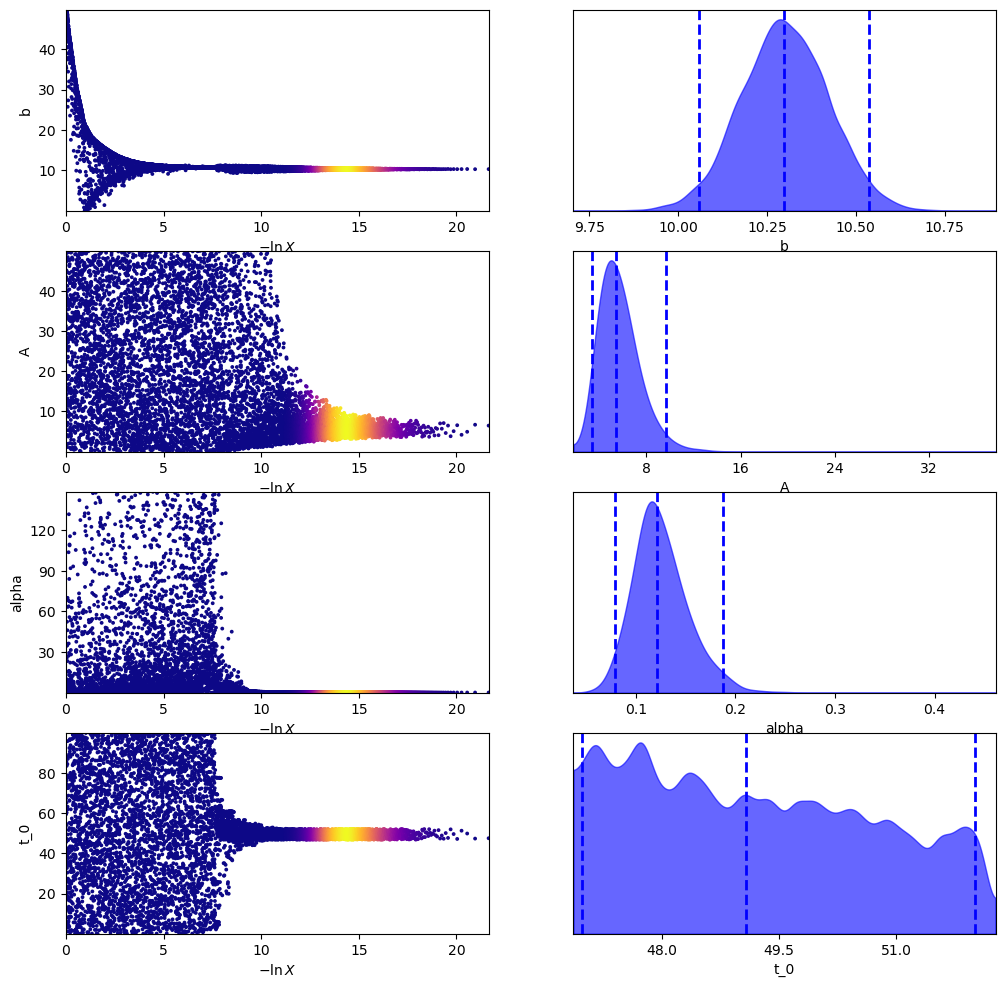

In [38]:
from dynesty import plotting as dyplot

labels = ["b", "A", "alpha", "t_0"]
fig, axes = dyplot.traceplot(sampler.results, labels=labels)
plt.show()

Seem's that the method did well. 

It's very importnat to deal with wheigt: if use dynesti tool weight are always taken wile using general corner one should be carefoul about them.

In [28]:
from dynesty import utils as dyfunc

weights = np.exp(sampler.results['logwt'] - sampler.results['logz'][-1])
samples_equal = dyfunc.resample_equal(samples, weights)

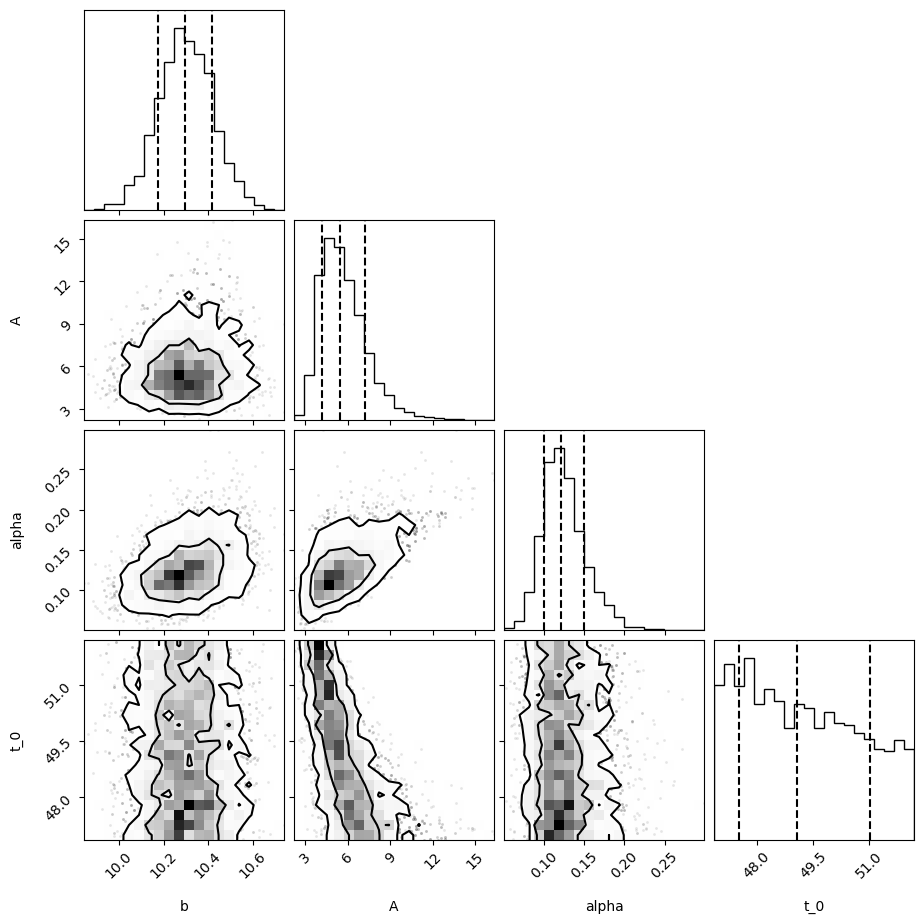

In [22]:
import corner as corner

fig = corner.corner(
    samples_equal, 
    labels=labels, 
    levels=[0.68, 0.95],
    quantiles=[0.16, 0.5, 0.84]
)
plt.show()

In [25]:
median_params = np.median(samples_equal, axis=0)
percentiles_params = np.percentile(samples_equal, [5, 95], axis=0)

print("Parameter estimates:")
for i, param in enumerate(labels):
    print(f"{param}: {median_params[i]:.3f} (+{percentiles_params[1, i] - median_params[i]:.3f}, -{median_params[i] - percentiles_params[0, i]:.3f})")

Parameter estimates:
b: 10.298 (+0.200, -0.195)
A: 5.465 (+3.355, -1.842)
alpha: 0.121 (+0.055, -0.036)
t_0: 49.086 (+2.754, -2.004)


*Disclaimer* : the fact that the sample is limited give a underestimeted error. One should run for intnìance a Bootstrap.

**Try another Model**

Let's check how evidence eneuble us to determine best modell selection.

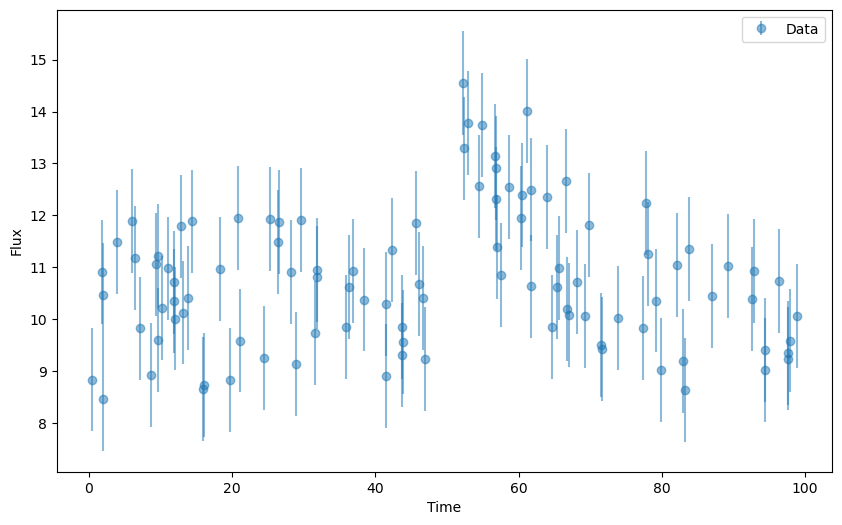

In [31]:
plt.figure(figsize=(10, 6))
plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

In [29]:
# Define the model
def Model(t, b, A, sigma, t0):
    return  b + A * np.exp(-0.5 * ((t - t0) / sigma) ** 2)

# Define the log-likelihood
def logLikelihood(theta, t, flux, error):
    b, A, sigma, t0 = theta
    model = Model(t, b, A, sigma, t0)
    logL = -0.5 * np.sum(((flux - model) / error) ** 2)
    return logL

# Define the prior transformation
def priorTransform(u):
    b = 50 * u[0]  # Map u[0] from [0, 1] to [0, 50]
    A = 50 * u[1]  # Map u[1] from [0, 1] to [0, 50]
    sigma = 50 * u[2]  # Map u[2] from [0, 1] to [0, 50]
    t0 = 100 * u[3]  # Map u[3] from [0, 1] to [0, 100]
    return b, A, sigma, t0

In [39]:
gauss_sampler = dynesty.NestedSampler(logLikelihood, priorTransform, ndim, nlive = 500, logl_args=(time, flux, error))
gauss_sampler.run_nested()
gauss_samples = gauss_sampler.results['samples']

2410it [00:01, 952.97it/s, bound: 6 | nc: 6 | ncall: 22157 | eff(%): 10.877 | loglstar:   -inf < -100.341 <    inf | logz: -108.578 +/-  0.121 | dlogz: 37.828 >  0.509]    /opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
3966it [00:12, 51.53it/s, bound: 66 | nc: 200 | ncall: 66827 | eff(%):  5.935 | loglstar:   -inf < -86.690 <    inf | logz: -93.521 +/-  0.109 | dlogz: 28.622 >  0.509]/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping

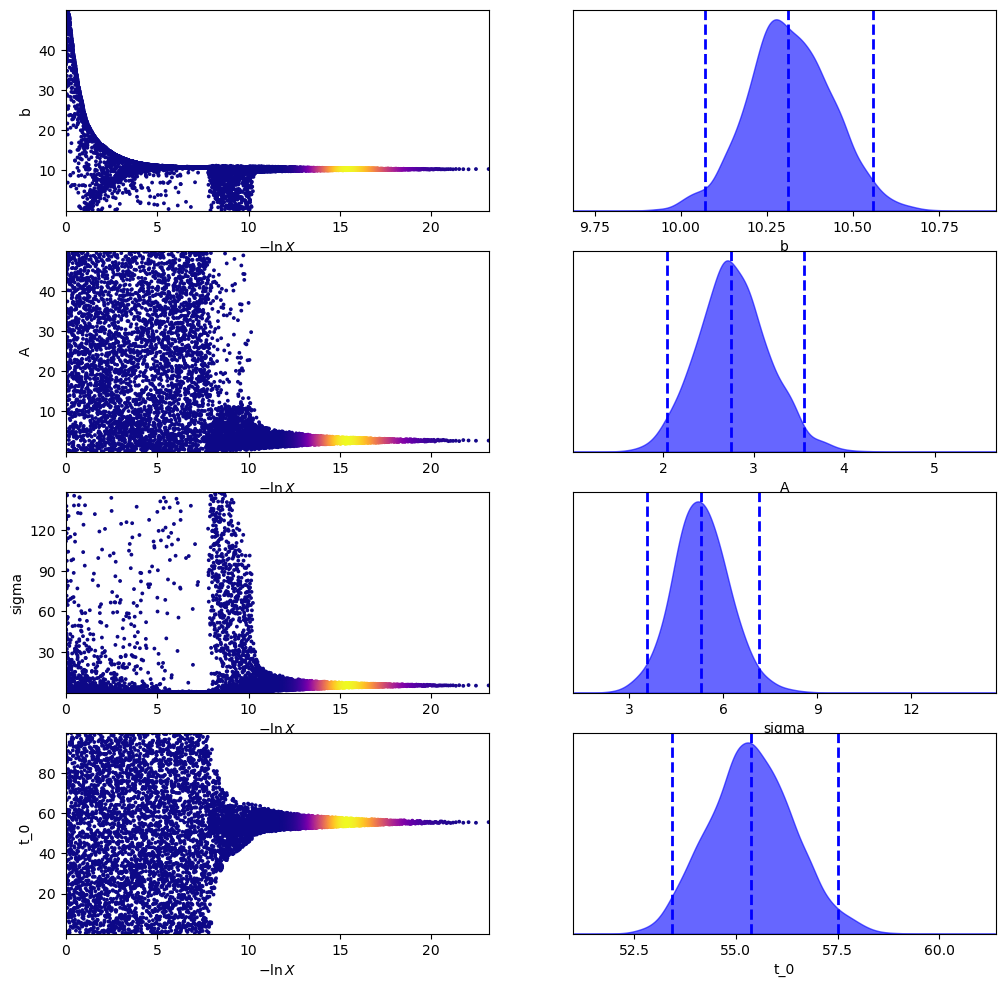

In [41]:
from dynesty import plotting as dyplot

labels = ["b", "A", "sigma", "t_0"]
fig, axes = dyplot.traceplot(gauss_sampler.results, labels=labels)
plt.show()

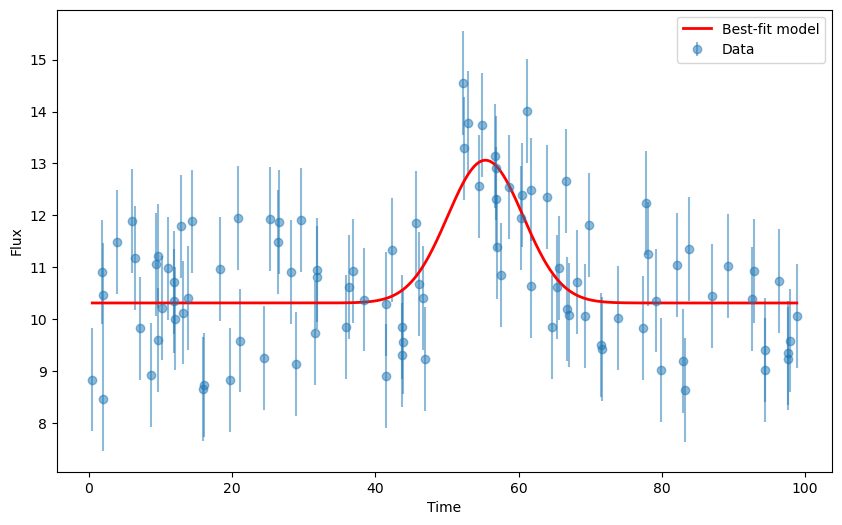

In [45]:
t_fit = np.linspace(time.min(), time.max(), 500)
gauss_weights = np.exp(gauss_sampler.results['logwt'] - gauss_sampler.results['logz'][-1])
gauss_samples_equal = dyfunc.resample_equal(gauss_samples, gauss_weights)
gauss_median_params = np.median(gauss_samples_equal, axis=0)
flux_fit = Model(t_fit, *gauss_median_params)

plt.figure(figsize=(10, 6))
plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.5)
plt.plot(t_fit, flux_fit, color='red', lw=2, label='Best-fit model')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()